# Visual: Truncated vs Censored

A picture worth a thousand summary tables. We simulate a simple
linear DGP, observe it through either truncation or censoring at the
same thresholds, fit `censtrunc` to each, and overlay the model's
predicted conditional mean as a band of asymptotic uncertainty.

This mirrors the style of the well-known `pymc-devs` GLM-truncated-censored-regression demonstration, but uses our
frequentist MLE instead of MCMC: the band is built by sampling
parameters from the asymptotic distribution
$\hat{\theta} \sim \mathcal{N}(\hat{\theta}_{\mathrm{MLE}},\,\widehat{\mathrm{Var}}(\hat{\theta}_{\mathrm{MLE}}))$
and drawing one prediction curve per sample.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from censtrunc import CensoredRegression, TruncatedRegression
from censtrunc._means import value_for_kind
from censtrunc._utils import _prepare_design_matrix

rng = np.random.default_rng(2026)
n = 250
x = rng.uniform(-10, 10, size=n)
sigma_true = 2.0
y_star = 1.0 * x + rng.normal(scale=sigma_true, size=n)
L, R = -5.0, 5.0

**Truncated dataset:** observations with $y \notin (L, R)$ are dropped entirely. **Censored dataset:** they are clipped to the nearest threshold. The latent linear function $y = x$ is the same in both.

In [2]:
mask = (y_star > L) & (y_star < R)
x_t, y_t = x[mask], y_star[mask]
x_c, y_c = x.copy(), np.clip(y_star, L, R)

mt = TruncatedRegression(left=L, right=R).fit(x_t.reshape(-1, 1), y_t)
mc = CensoredRegression(left=L, right=R).fit(x_c.reshape(-1, 1), y_c)
print(f'truncated:  n={len(y_t)}, beta_hat = {mt.coef_.round(3)}')
print(f'censored:   n={len(y_c)}, beta_hat = {mc.coef_.round(3)}')

truncated:  n=146, beta_hat = [-0.003  0.946]
censored:   n=250, beta_hat = [0.059 0.939]


Now we build a prediction band from asymptotic uncertainty. We draw 200 parameter vectors from the asymptotic normal distribution of $\hat\theta$, compute the corresponding conditional mean curve (truncated on the left, censored on the right), and plot them with low opacity. The pile-up at the censoring thresholds is shown in red on the right.

In [3]:
def prediction_band(model, x_grid, kind, n_draws=200, seed=0):
    rng = np.random.default_rng(seed)
    samples = rng.multivariate_normal(model.params_, model.cov_params_, size=n_draws)
    samples = samples[samples[:, 0] > 0]   # keep only feasible sigma > 0
    Xg, _ = _prepare_design_matrix(x_grid.reshape(-1, 1), fit_intercept=True)
    curves = np.empty((samples.shape[0], x_grid.size))
    for i, theta in enumerate(samples):
        sigma, beta = theta[0], theta[1:]
        curves[i] = value_for_kind(
            beta, sigma, Xg,
            model._left, model._right, model._has_left, model._has_right, kind,
        )
    return curves

x_grid = np.linspace(-10, 10, 300)
curves_t = prediction_band(mt, x_grid, kind='truncated')
curves_c = prediction_band(mc, x_grid, kind='censored')

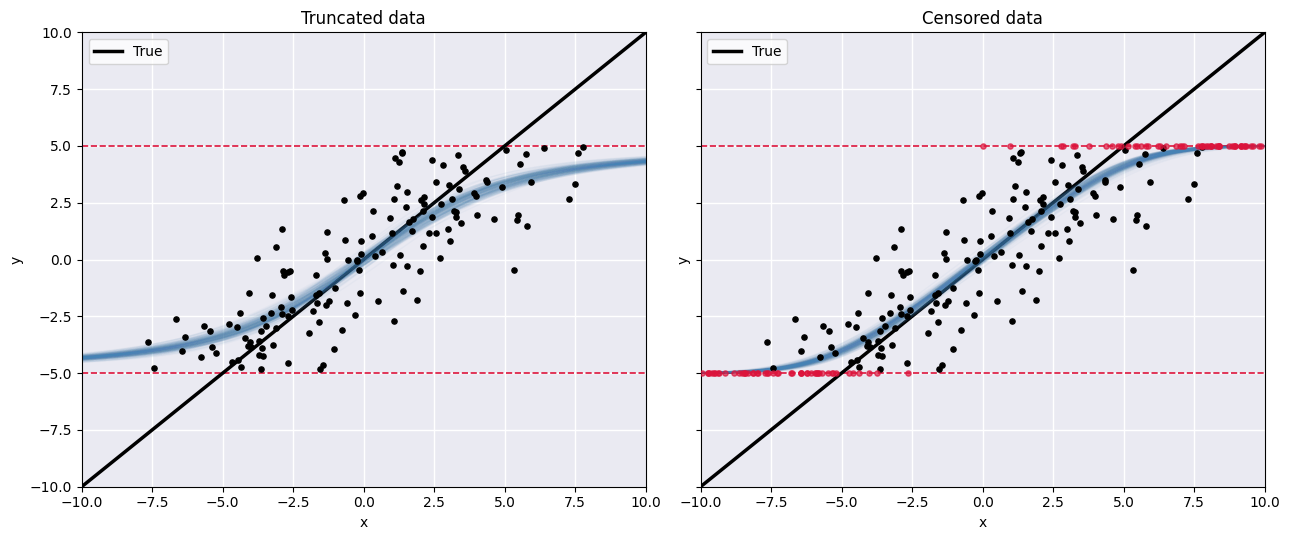

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax in axes:
    ax.set_facecolor('#eaeaf2')
    ax.grid(True, color='white', linewidth=1)
    ax.axhline(L, color='crimson', linestyle='--', linewidth=1.2)
    ax.axhline(R, color='crimson', linestyle='--', linewidth=1.2)
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.plot(x_grid, x_grid, color='black', linewidth=2.5, label='True')

# Left panel: truncated
ax = axes[0]
ax.set_title('Truncated data')
for c in curves_t:
    ax.plot(x_grid, c, color='steelblue', alpha=0.04, linewidth=1)
ax.scatter(x_t, y_t, c='black', s=14, zorder=5)
ax.legend(loc='upper left')

# Right panel: censored
ax = axes[1]
ax.set_title('Censored data')
for c in curves_c:
    ax.plot(x_grid, c, color='steelblue', alpha=0.04, linewidth=1)
is_at_bound = (y_c == L) | (y_c == R)
ax.scatter(x_c[~is_at_bound], y_c[~is_at_bound], c='black', s=14, zorder=5)
ax.scatter(x_c[is_at_bound],  y_c[is_at_bound],  c='crimson', s=14, zorder=5, alpha=0.7)
ax.legend(loc='upper left')

plt.tight_layout(); plt.show()

**What to look for.**

- The black line is the true linear relation $y^* = x$.
- The blue band is the model's MLE prediction with asymptotic
  uncertainty; on the **left** it bends inside $(L, R)$ because the
  truncated mean $\mathbb E[Y \mid X, L<Y<R]$ is shrunk toward the interval centre; on the **right** it flattens near each threshold because the censored mean $\mathbb E[Y\mid X]$ mixes the latent linear part with the threshold mass.
- Red dots on the right panel are the censored pile-ups at $y=L$ and $y=R$. The truncated dataset has no such pile-ups because those observations are absent entirely.
- Both fitted curves are close to the true line in the interior, where the data are most informative; both lose precision near and beyond the thresholds, but neither shows the strong attenuation toward zero that OLS would suffer.